In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
import os

print(os.getcwd())

D:\projects\AI-Stock-Analytics-System\notebooks


In [6]:
import pandas as pd

DATA_PATH = r"D:\projects\AI-Stock-Analytics-System\data\final\feature_engineered_stock_data.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (418075, 49)


,Date,Close,High,Low,Open,Volume,Ticker,Daily_Return,MA5,MA10,...,NIFTY_Close,NIFTY_Return,Relative_Strength,Bank_Relative_Strength,Volume_Ratio,Prev_Close,Gap_Percentage,ATR_Percentage,Bull_Market,Target_Signal_Balanced
0,2008-04-02,621.754211,628.870167,618.566878,620.123469,299209.0,ACC,0.017097,615.431458,602.463446,...,4754.200195,0.003091,-0.292012,-2.473786,0.618517,611.302795,1.442930,4.385541,0,SELL
1,2008-04-03,612.933411,621.161184,604.149660,613.748759,586458.0,ACC,-0.014187,615.987378,607.448297,...,4771.600098,0.003660,-0.380177,0.378572,1.189842,621.754211,-1.287559,4.336049,0,HOLD
2,2008-04-04,615.861389,637.357424,608.634274,637.357424,388972.0,ACC,0.004777,614.845886,611.421350,...,4647.000000,-0.026113,2.616062,2.983536,0.854275,612.933411,3.984774,4.340324,0,HOLD
3,2008-04-07,617.158508,622.643721,608.560113,611.525083,486842.0,ACC,0.002106,615.802063,613.493109,...,4761.200195,0.024575,-2.455397,-4.386639,1.065793,615.861389,-0.704104,4.184831,0,SELL
4,2008-04-08,611.784546,620.420040,600.480597,620.420040,483884.0,ACC,-0.008708,615.898413,614.082391,...,4709.649902,-0.010827,1.074009,-0.452192,1.110288,617.158508,0.528476,4.152850,0,SELL


In [7]:
print(df.columns.tolist())

['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker', 'Daily_Return', 'MA5', 'MA10', 'MA20', 'MA50', 'EMA20', 'RSI', 'EMA12', 'EMA26', 'MACD', 'Signal_Line', 'MACD_Histogram', 'Upper_Band', 'Lower_Band', 'Volatility', 'Lag1', 'Lag2', 'Lag3', 'Target_Close', 'Future_Return', 'Target_Signal', 'ATR', 'ADX', 'OBV', 'Stochastic', 'CCI', 'Price_vs_MA20', 'EMA_Diff', 'BB_Width', 'India_VIX', 'BankNIFTY_Close', 'BankNIFTY_Return', 'NIFTY_Close', 'NIFTY_Return', 'Relative_Strength', 'Bank_Relative_Strength', 'Volume_Ratio', 'Prev_Close', 'Gap_Percentage', 'ATR_Percentage', 'Bull_Market', 'Target_Signal_Balanced']


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418075 entries, 0 to 418074
Data columns (total 49 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Date                    418075 non-null  object 
 1   Close                   418075 non-null  float64
 2   High                    418075 non-null  float64
 3   Low                     418075 non-null  float64
 4   Open                    418075 non-null  float64
 5   Volume                  418075 non-null  float64
 6   Ticker                  418075 non-null  object 
 7   Daily_Return            418075 non-null  float64
 8   MA5                     418075 non-null  float64
 9   MA10                    418075 non-null  float64
 10  MA20                    418075 non-null  float64
 11  MA50                    418075 non-null  float64
 12  EMA20                   418075 non-null  float64
 13  RSI                     418075 non-null  float64
 14  EMA12               

In [10]:
print("Missing values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

Missing values:
Date              0
Close             0
High              0
Low               0
Open              0
Volume            0
Ticker            0
Daily_Return      0
MA5               0
MA10              0
MA20              0
MA50              0
EMA20             0
RSI               0
EMA12             0
EMA26             0
MACD              0
Signal_Line       0
MACD_Histogram    0
Upper_Band        0
dtype: int64


In [11]:
numeric_features = df.select_dtypes(include=np.number).columns.tolist()

exclude_columns = [
    "Target_Close",
    "Future_Return",
    "Bull_Market"
]

outlier_features = [
    col for col in numeric_features
    if col not in exclude_columns
]

print("Features checked for outliers:")
print(outlier_features)
print("\nNumber of features:", len(outlier_features))

Features checked for outliers:
['Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'MA5', 'MA10', 'MA20', 'MA50', 'EMA20', 'RSI', 'EMA12', 'EMA26', 'MACD', 'Signal_Line', 'MACD_Histogram', 'Upper_Band', 'Lower_Band', 'Volatility', 'Lag1', 'Lag2', 'Lag3', 'ATR', 'ADX', 'OBV', 'Stochastic', 'CCI', 'Price_vs_MA20', 'EMA_Diff', 'BB_Width', 'India_VIX', 'BankNIFTY_Close', 'BankNIFTY_Return', 'NIFTY_Close', 'NIFTY_Return', 'Relative_Strength', 'Bank_Relative_Strength', 'Volume_Ratio', 'Prev_Close', 'Gap_Percentage', 'ATR_Percentage']

Number of features: 42


In [12]:
outlier_summary = []

for col in outlier_features:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier %": outlier_count / len(df) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary = outlier_summary.sort_values(
    "Outlier %",
    ascending=False
)

outlier_summary

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
16,MACD_Histogram,-8.684571e-01,9.098688e-01,1.778326e+00,-3.535946e+00,3.577358e+00,93684,22.408420
14,MACD,-1.742555e+00,4.755645e+00,6.498200e+00,-1.148986e+01,1.450294e+01,88912,21.266998
29,EMA_Diff,-1.742555e+00,4.755645e+00,6.498200e+00,-1.148986e+01,1.450294e+01,88912,21.266998
15,Signal_Line,-1.606791e+00,4.590274e+00,6.197065e+00,-1.090239e+01,1.388587e+01,88243,21.106978
18,Lower_Band,7.703760e+01,7.336544e+02,6.566168e+02,-9.078876e+02,1.718580e+03,45834,10.963105
9,MA50,8.259304e+01,7.730063e+02,6.904132e+02,-9.530268e+02,1.808626e+03,45590,10.904742
8,MA20,8.293662e+01,7.810872e+02,6.981506e+02,-9.642893e+02,1.828313e+03,45509,10.885367
22,Lag3,8.304657e+01,7.837148e+02,7.006683e+02,-9.679558e+02,1.834717e+03,45502,10.883693
0,Close,8.315515e+01,7.849193e+02,7.017641e+02,-9.694910e+02,1.837565e+03,45501,10.883454
3,Open,8.326401e+01,7.855897e+02,7.023257e+02,-9.702246e+02,1.839078e+03,45499,10.882976


In [13]:
outlier_summary.head(15)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
16,MACD_Histogram,-0.868457,0.909869,1.778326,-3.535946,3.577358,93684,22.408420
14,MACD,-1.742555,4.755645,6.498200,-11.489856,14.502945,88912,21.266998
29,EMA_Diff,-1.742555,4.755645,6.498200,-11.489856,14.502945,88912,21.266998
15,Signal_Line,-1.606791,4.590274,6.197065,-10.902387,13.885871,88243,21.106978
18,Lower_Band,77.037601,733.654414,656.616813,-907.887618,1718.579633,45834,10.963105
9,MA50,82.593038,773.006284,690.413246,-953.026830,1808.626152,45590,10.904742
8,MA20,82.936615,781.087241,698.150625,-964.289323,1828.313179,45509,10.885367
22,Lag3,83.046570,783.714844,700.668274,-967.955841,1834.717255,45502,10.883693
0,Close,83.155151,784.919281,701.764130,-969.491043,1837.565475,45501,10.883454
3,Open,83.264007,785.589747,702.325739,-970.224602,1839.078356,45499,10.882976


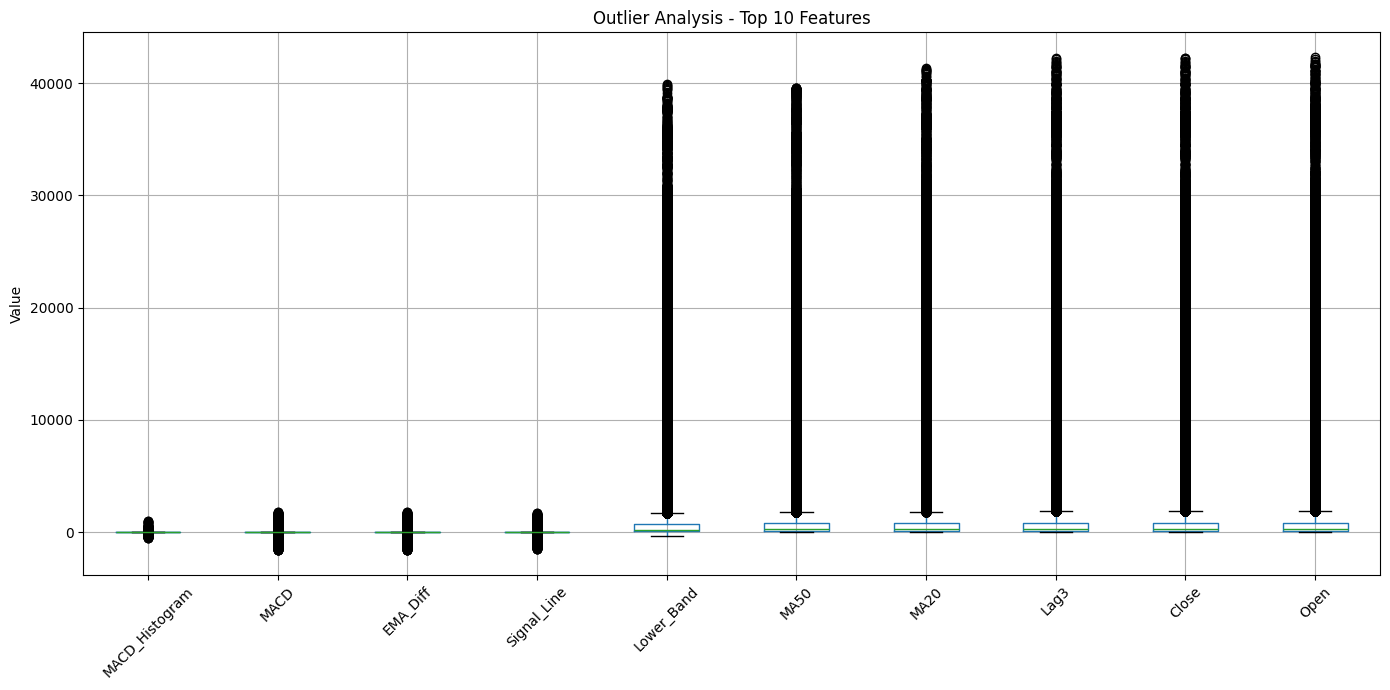

In [14]:
top_features = outlier_summary.head(10)["Feature"].tolist()

plt.figure(figsize=(14, 7))

df[top_features].boxplot(rot=45)

plt.title("Outlier Analysis - Top 10 Features")
plt.ylabel("Value")
plt.tight_layout()

plt.show()

In [15]:
check_features = [
    "Daily_Return",
    "Volatility",
    "Gap_Percentage",
    "ATR_Percentage",
    "Volume_Ratio",
    "NIFTY_Return",
    "BankNIFTY_Return"
]

outlier_summary[
    outlier_summary["Feature"].isin(check_features)
]

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
40,Gap_Percentage,-0.182360,0.579536,0.761896,-1.325205,1.722381,38897,9.303833
33,BankNIFTY_Return,-0.006904,0.007919,0.014823,-0.029138,0.030154,28848,6.900197
38,Volume_Ratio,0.603937,1.190769,0.586832,-0.276310,2.071016,25330,6.058722
5,Daily_Return,-0.010545,0.011350,0.021895,-0.043388,0.044193,23559,5.635113
35,NIFTY_Return,-0.005103,0.006345,0.011448,-0.022274,0.023516,22296,5.333014
41,ATR_Percentage,2.406960,3.839137,1.432177,0.258694,5.987402,21857,5.228009
19,Volatility,0.013912,0.024152,0.010240,-0.001449,0.039512,19637,4.697004


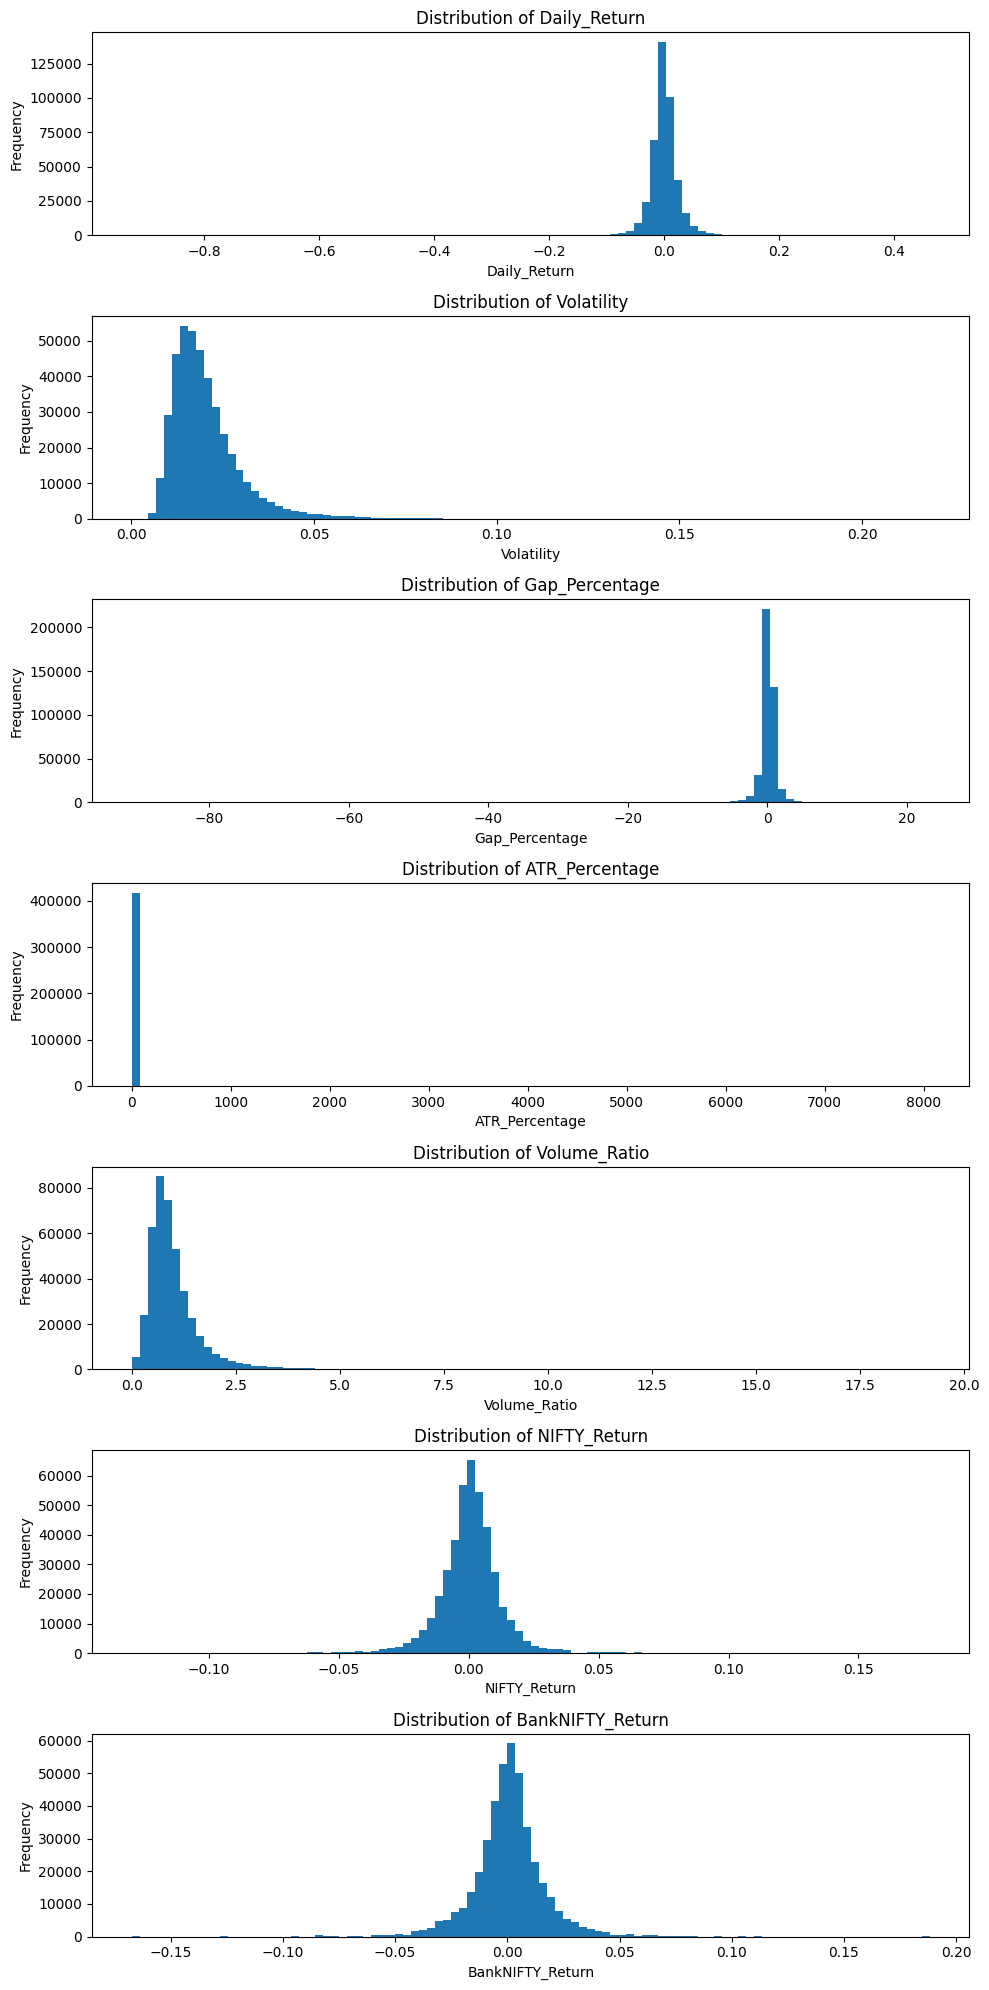

In [16]:
fig, axes = plt.subplots(
    len(check_features),
    1,
    figsize=(10, 20)
)

for ax, col in zip(axes, check_features):
    ax.hist(df[col], bins=100)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [17]:
features_to_check = [
    "Daily_Return",
    "Gap_Percentage",
    "ATR_Percentage",
    "Volume_Ratio",
    "NIFTY_Return",
    "BankNIFTY_Return"
]

for col in features_to_check:
    print("\n" + "=" * 60)
    print(col)
    print("=" * 60)

    print(
        df.loc[
            df[col].abs().nlargest(10).index,
            ["Date", "Ticker", "Close", col, "Target_Signal"]
        ].sort_values(col)
    )


Daily_Return
              Date      Ticker       Close  Daily_Return Target_Signal
38037   2008-05-26  BAJAJFINSV   48.534531     -0.926483           BUY
272638  2010-01-08   NESTLEIND  102.565109     -0.763338          HOLD
409043  2026-04-30        VEDL  271.549988     -0.648979          HOLD
37993   2008-03-14  BAJAJFINSV  757.982117     -0.637850          SELL
33551   2008-05-26  BAJAJ-AUTO  186.764099     -0.424336          SELL
187136  2019-11-19        IDEA    6.050000      0.359551           BUY
85204   2017-10-25       CANBK   74.463417      0.387260          SELL
187200  2020-02-19        IDEA    4.200000      0.400000           BUY
194279  2020-03-26  INDUSINDBK  420.269653      0.446731          SELL
315697  2017-10-25         PNB  182.175339      0.462012           BUY

Gap_Percentage
              Date      Ticker       Close  Gap_Percentage Target_Signal
38037   2008-05-26  BAJAJFINSV   48.534531      -91.137005           BUY
272638  2010-01-08   NESTLEIND  102.565109 

In [18]:
print(
    df.loc[
        df["ATR_Percentage"].nlargest(20).index,
        [
            "Date",
            "Ticker",
            "Close",
            "High",
            "Low",
            "ATR",
            "ATR_Percentage"
        ]
    ].sort_values("ATR_Percentage", ascending=False)
)

              Date Ticker     Close      High       Low         ATR  \
269187  2012-06-22   NBCC  3.386545  3.445378  3.235788  272.997585   
269188  2012-06-25   NBCC  3.430669  3.585105  3.390222  253.511940   
269189  2012-06-26   NBCC  3.441701  3.493179  3.401254  235.410511   
269190  2012-06-27   NBCC  3.419639  3.491341  3.384708  218.603091   
269191  2012-06-28   NBCC  3.456409  3.485826  3.404930  202.994363   
269192  2012-06-29   NBCC  3.458248  3.524435  3.434347  188.501200   
269193  2012-07-02   NBCC  3.430669  3.489501  3.428831  175.041162   
269194  2012-07-03   NBCC  3.482148  3.511564  3.392061  162.546758   
269195  2012-07-04   NBCC  3.524435  3.548335  3.439862  150.944023   
269196  2012-07-05   NBCC  3.677031  3.787341  3.493179  140.183319   
269197  2012-07-06   NBCC  3.675192  3.713800  3.572235  130.180337   
269198  2012-07-09   NBCC  3.732187  3.768957  3.658646  120.889620   
269199  2012-07-10   NBCC  3.697255  3.824113  3.680708  112.264891   
269200

In [19]:
print(
    df.loc[
        df["Gap_Percentage"].nsmallest(20).index,
        [
            "Date",
            "Ticker",
            "Open",
            "Prev_Close",
            "Gap_Percentage"
        ]
    ]
)

              Date      Ticker         Open   Prev_Close  Gap_Percentage
38037   2008-05-26  BAJAJFINSV    57.653372   650.495361      -91.137005
272638  2010-01-08   NESTLEIND   105.046342   433.382996      -75.761314
37993   2008-03-14  BAJAJFINSV   738.910309  2093.008545      -64.696259
409043  2026-04-30        VEDL   289.500000   773.599976      -62.577558
47020   2008-06-09  BALKRISIND    39.078009    49.773033      -21.487587
308922  2008-06-09         PFC    17.414055    21.929749      -20.591635
113182  2025-01-02      CONCOR   612.976943   770.130493      -20.406094
299832  2024-02-02       PAYTM   487.200012   609.000000      -19.999998
299831  2024-02-01       PAYTM   609.000000   761.200012      -19.994746
14033   2020-03-23       ALKEM  1770.742011  2210.580811      -19.896979
24600   2008-05-12  AUROPHARMA    23.454588    29.235701      -19.774156
272707  2010-04-23   NESTLEIND    95.067027   118.301498      -19.640048
208356  2009-07-27         IRB     5.716380     7.1